In [1]:
from ggner_3d.cm import MCOOLS_PATH_DICT, CLR_CONNS
SAMPLE_NAMES = list(MCOOLS_PATH_DICT.keys())
from ggner_3d import plotting
plotting.update_rcparams()
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cooler

genove_out_path = '/home/carlos/Clone/ggner-3d/data/genova_trans'

/tmp/ipykernel_129803/4276516029.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(), rotation=45)


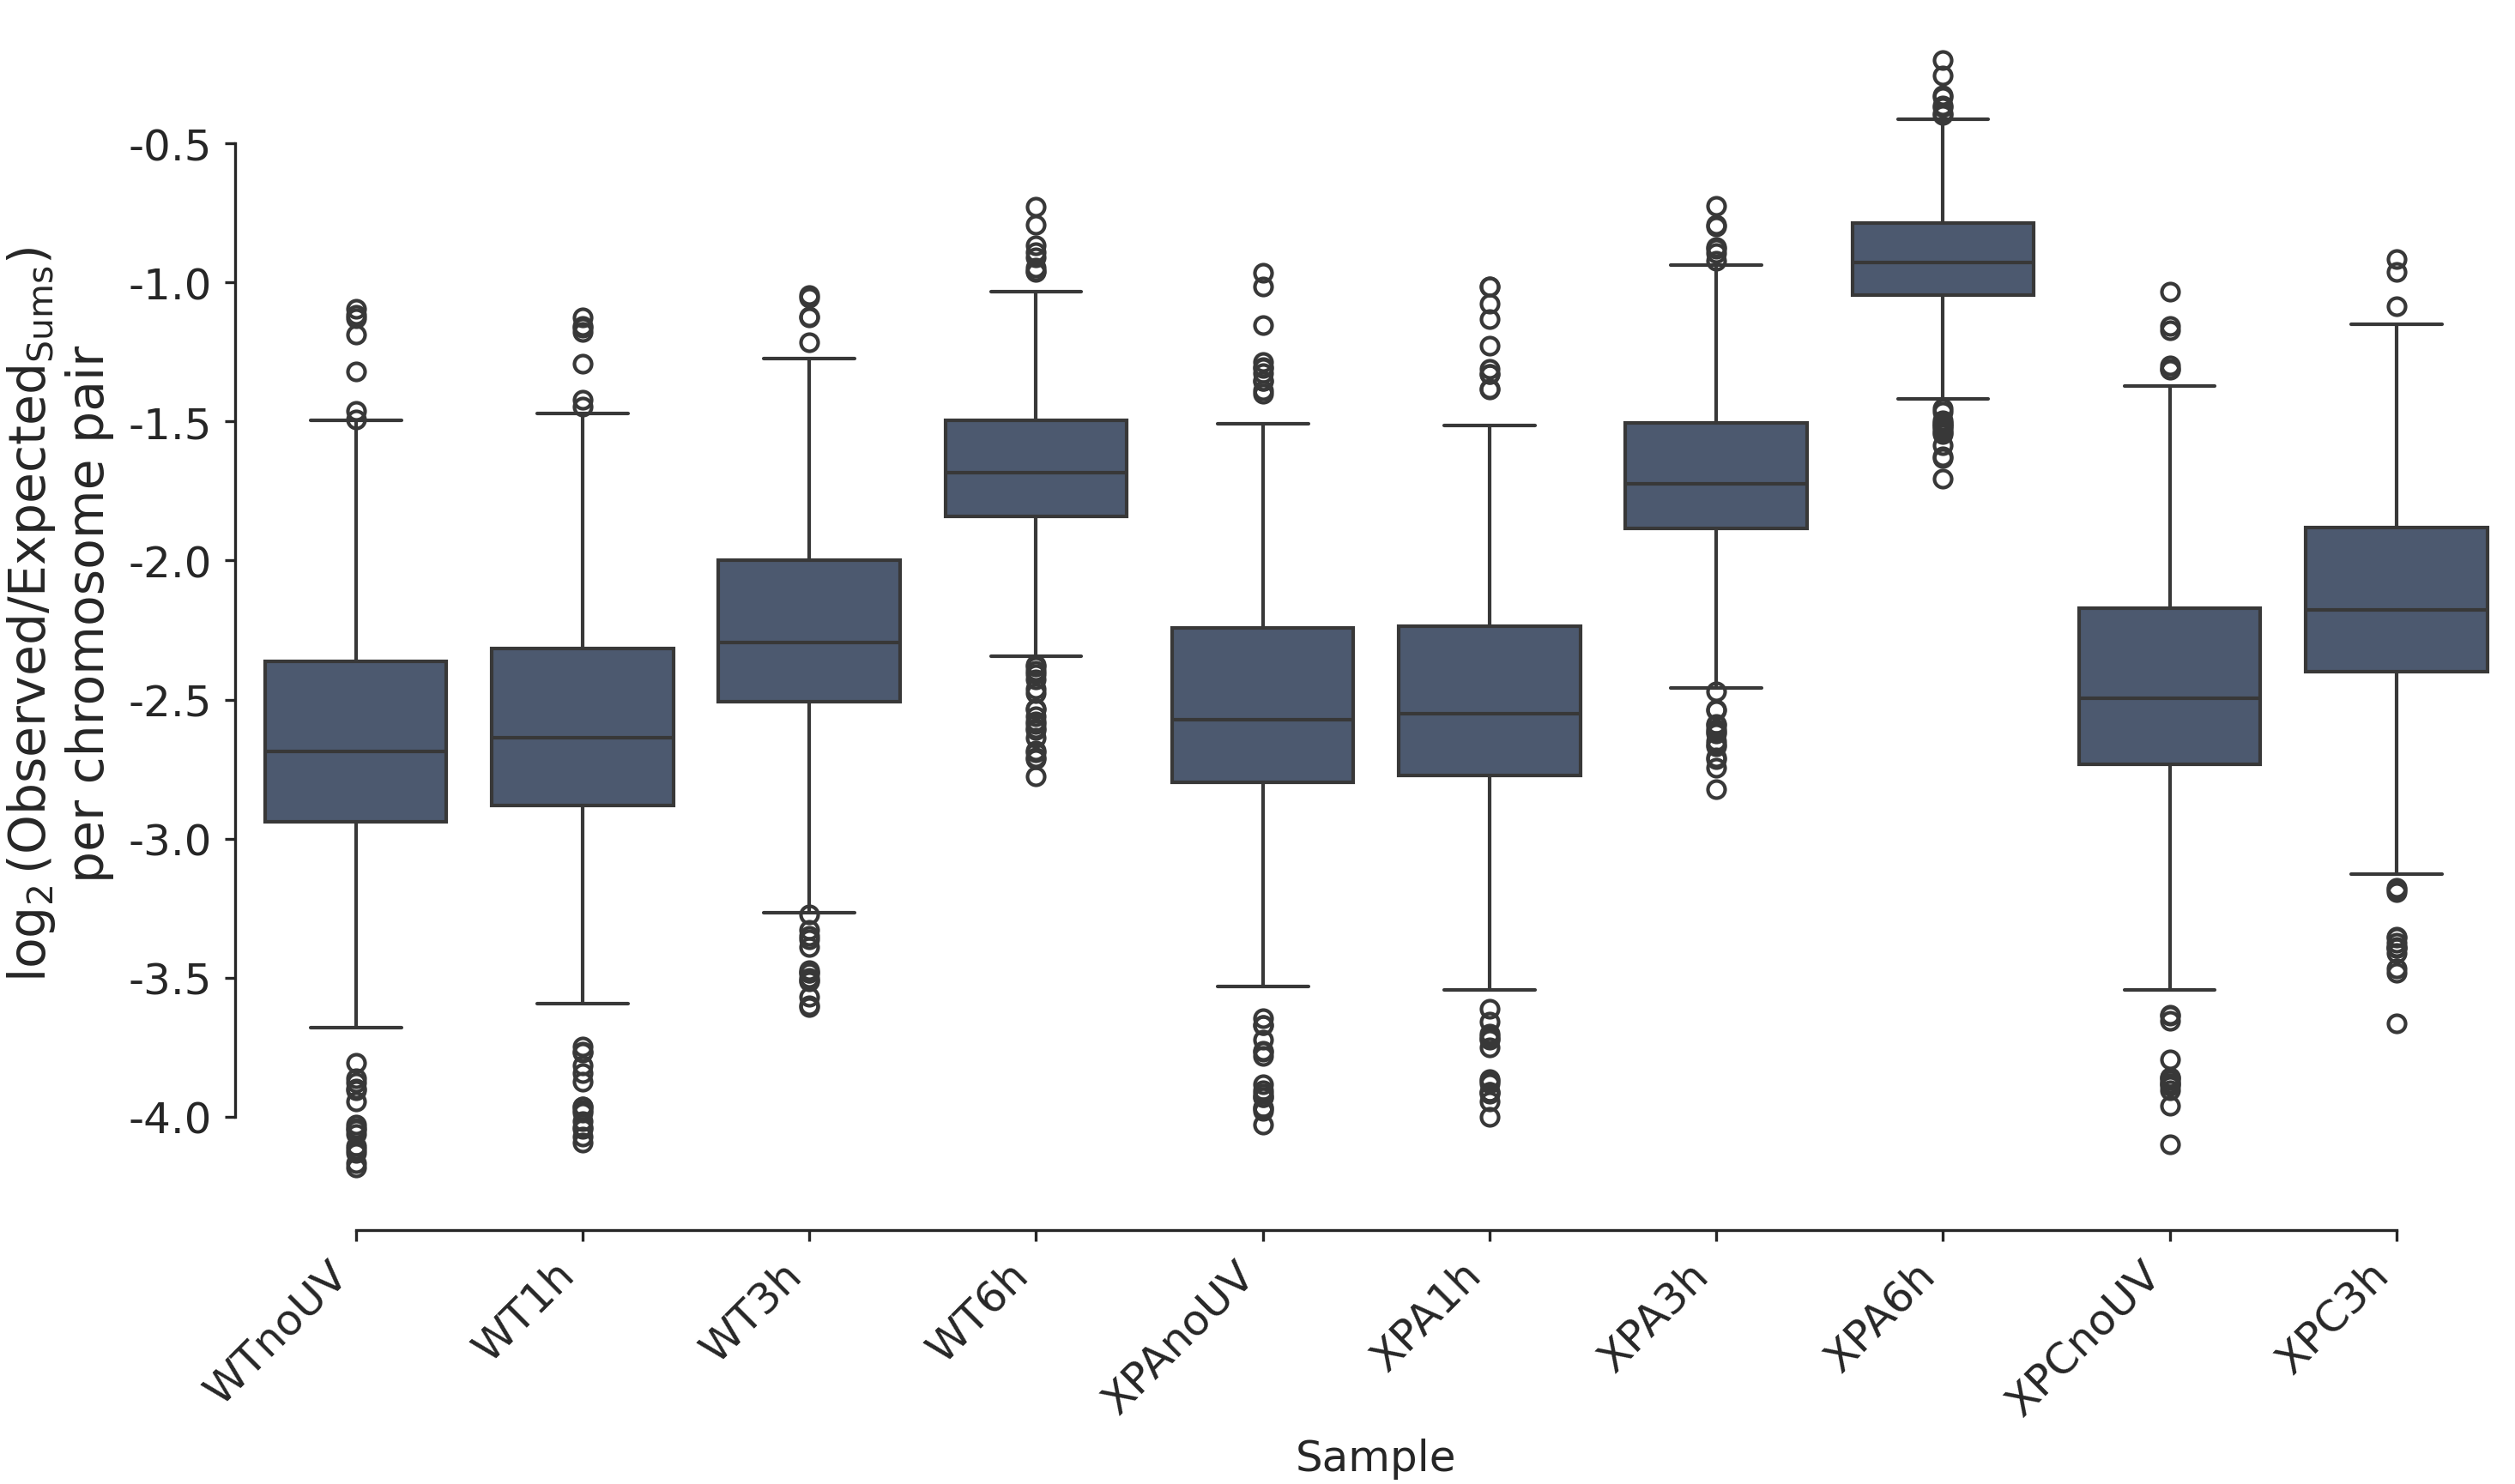

In [2]:
expected_type = 'sums'
current_path = f'{genove_out_path}/log2_obsexp_{expected_type}'
df_ = {
    sample_name: pd.read_csv(f'{current_path}/{sample_name}_log2_obsexp.tsv', sep='\t').set_index('Unnamed: 0') for sample_name in SAMPLE_NAMES
}
plot_dict = {
    'sample_name': [],
    'values': []
}
for sample in SAMPLE_NAMES:
    current_mtx = df_[sample].to_numpy()
    # mask diagonal
    np.fill_diagonal(current_mtx, np.nan)
    # get upper triangle
    triu_indices = np.triu_indices_from(current_mtx, k=1)
    current_vals = current_mtx[triu_indices]
    plot_dict['sample_name'].extend([sample] * len(current_vals))
    plot_dict['values'].extend(current_vals.tolist())

fig, ax1 = plt.subplots(figsize=(10, 6))

s = sns.boxplot(x='sample_name', y='values', data=plot_dict, ax=ax1, color=plotting.COLORS[0])
# rotate x labels
s.set_xticklabels(s.get_xticklabels(), rotation=45)
plotting.despine(ax1)

ax1.set_ylabel(
    r"$\log_{2}(\mathrm{Observed}/\mathrm{Expected}_{\mathrm{Sums}})$"
    "\nper chromosome pair"
,
    fontsize=14)
ax1.set_xlabel("Sample")

# make x labels more readable
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# make y ticks more readable
y_ticks = ax1.get_yticks()
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([f"{y:.1f}" for y in y_ticks], fontsize=12)

plt.tight_layout()
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/boxplot_log2_obsexp_sums_per_chrompair.svg')

In [3]:
def cis_trans_percent_balanced_ignore_nan(c, weight_name="sweight"):
    # extents per chromosome from bins table (robust for fixed/variable bins)
    bins_chrom = c.bins()[:]["chrom"].to_numpy()
    chrom_names = list(c.chromnames)

    ext = {}
    for chrom in chrom_names:
        idx = np.flatnonzero(bins_chrom == chrom)
        if len(idx):
            ext[chrom] = (int(idx[0]), int(idx[-1]) + 1)

    M = c.matrix(balance=weight_name, sparse=True)

    def finite_sum_sparse(mat):
        """Sum only finite stored values of a sparse matrix."""
        coo = mat.tocoo()
        data = coo.data
        return float(data[np.isfinite(data)].sum())

    def finite_sum_sparse_upper(mat):
        """Sum only finite values in the upper triangle (incl diagonal) of sparse mat."""
        coo = mat.tocoo()
        mask = (coo.row <= coo.col) & np.isfinite(coo.data)
        return float(coo.data[mask].sum())

    trans_sum = 0.0
    for i, ci in enumerate(chrom_names):
        si, ei = ext[ci]
        for cj in chrom_names[i+1:]:
            sj, ej = ext[cj]
            trans_sum += finite_sum_sparse(M[si:ei, sj:ej])

    cis_sum = 0.0
    for ci in chrom_names:
        si, ei = ext[ci]
        cis_sum += finite_sum_sparse_upper(M[si:ei, si:ei])

    total = cis_sum + trans_sum
    cis_pct = 100.0 * cis_sum / total if total else np.nan
    trans_pct = 100.0 * trans_sum / total if total else np.nan

    return {
        "cis_sum_balanced": cis_sum,
        "trans_sum_balanced": trans_sum,
        "cis_pct": cis_pct,
        "trans_pct": trans_pct,
    }

In [4]:
clrs_ = CLR_CONNS(resolution=1_000_000)
stats_dict_raw = {}
weight_name = 'sweight'
for sample_name, clr in clrs_.items():
    print(f'Processing sample: {sample_name}')
    stats = cis_trans_percent_balanced_ignore_nan(clr, weight_name=weight_name)
    stats_dict_raw[sample_name] = stats

Processing sample: WTnoUV
Processing sample: WT1h
Processing sample: WT3h
Processing sample: WT6h
Processing sample: XPAnoUV
Processing sample: XPA1h
Processing sample: XPA3h
Processing sample: XPA6h
Processing sample: XPCnoUV
Processing sample: XPC3h


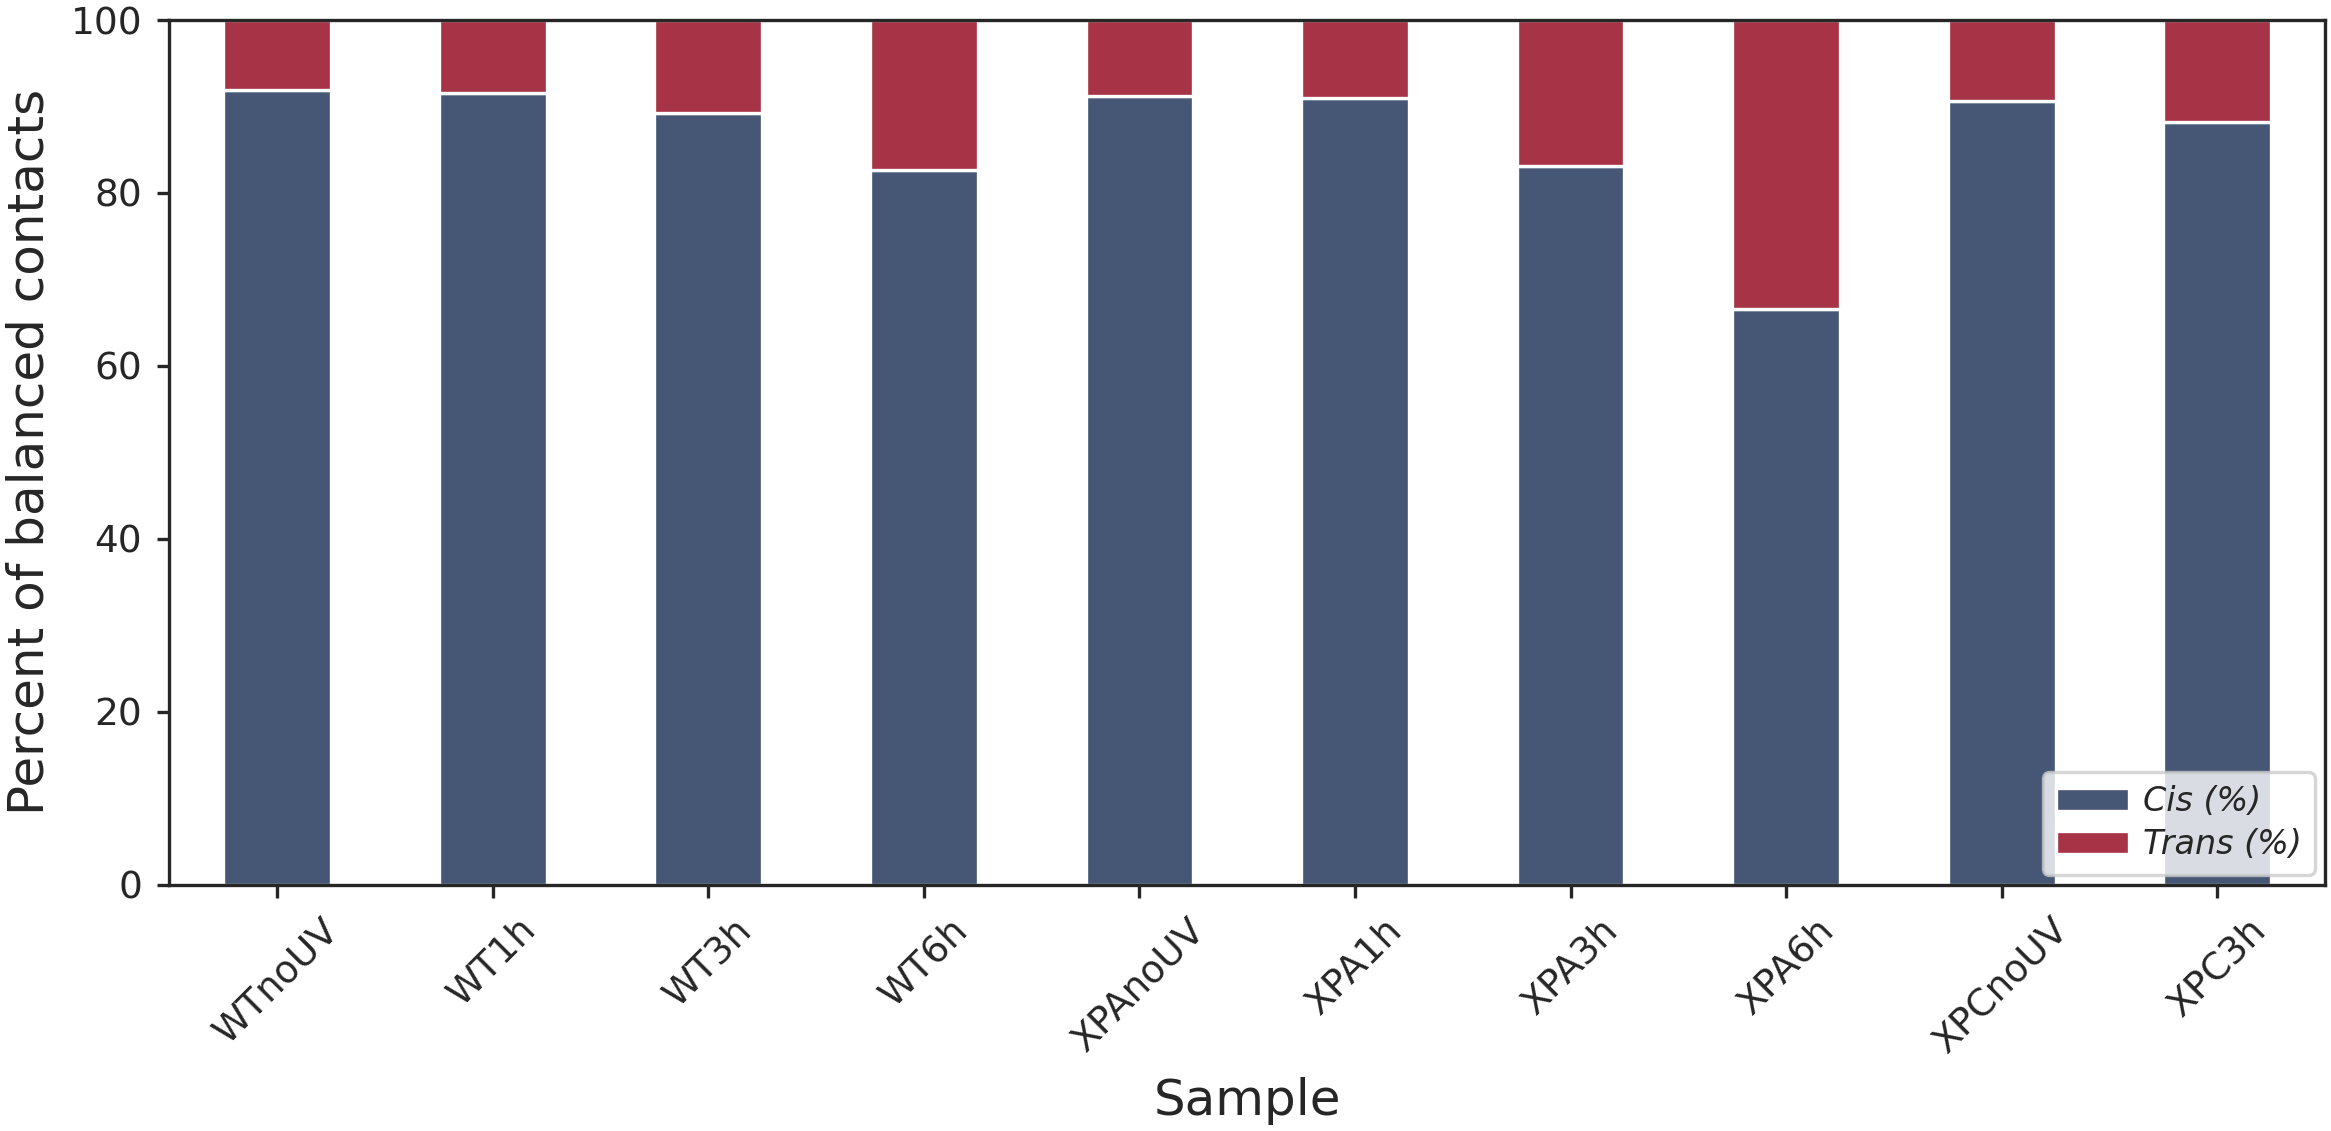

In [5]:
order = list(clrs_.keys())

df = (pd.DataFrame.from_dict(stats_dict_raw, orient="index")
        [["cis_pct", "trans_pct"]]
        .rename(columns={"cis_pct": "Cis (%)", "trans_pct": "Trans (%)"}))

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Cis (%)", "Trans (%)"])

# enforce order from clrs_.keys()
df = df.reindex(order).dropna(how="all")

colors = plotting.COLORS[:2]

fig, ax = plt.subplots(figsize=(10, 6))

df.plot(kind="bar", stacked=True, figsize=(max(8, 0.35 * len(df)), 4), color=colors, ax=ax)
# rotate x tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

ax.set_ylabel("Percent of balanced contacts")
ax.set_xlabel("Sample")
ax.set_ylim(0, 100)

leg = ax.legend(loc="lower right")
for t in leg.get_texts():
    t.set_fontstyle("italic")

plt.tight_layout()
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/barplot_cis_trans_percent_balanced.svg')